In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.greedy import GreedyLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 9)[0]]
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]

def make_converter(params: Params):
    return GreedyLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0520 | Max: 0.2112 | Mean: 0.1336 | Std: 0.0507
Min: 0.0519 | Max: 0.2095 | Mean: 0.1365 | Std: 0.0513
Min: 0.0624 | Max: 0.2029 | Mean: 0.1379 | Std: 0.0504
Min: 0.0587 | Max: 0.2008 | Mean: 0.1389 | Std: 0.0517
Min: 0.0558 | Max: 0.1987 | Mean: 0.1381 | Std: 0.0528


C:\Users\wojte\AppData\Local\Temp\ipykernel_28652\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


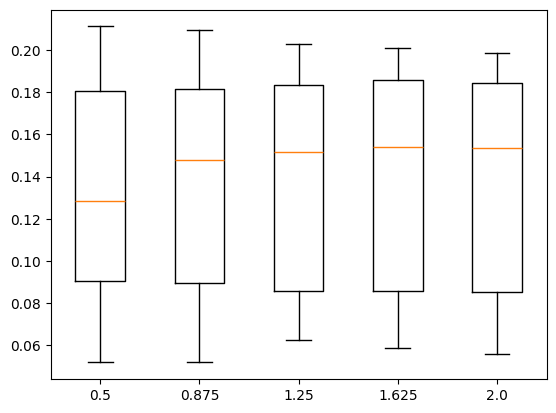

In [2]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [3]:
from PIL import Image
from converters.img_converter import ImgConverter
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = GreedyLineSearch(symbols=SYMBOLS,
                             font=FONT)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, None, MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------
 | ^^NNNNNNNNNNNNNNNNNNNyL- | NNNNNNNNNDNNNNNNNNNNNNNN | 
 | LLLLLLDLLLLLLLLLL``````` | NNNNNNNNDNNNNNNNNNNNNNND | 
 | NNNNNNNNNNNNNNNNNNNNNNNN | L`DDNNNNNN`L`^NNNLDDNLDN | 
 | NNNNNNNNNNNNNNNNNNNNNNNN | NNNNNNNN```````DNNDNNNNN | 
 | NNNNNNL`L``DNNNNNNNNNNNN | NNNNNNNNNN`````NNNNNNNNN | 
 | NNNNNNNDNNNNNNNNNNNNNNNN | DNNNNNNNNNL````NNNNNNNNN | 
 | NNNNNNNNNNNNNNNNNNNNNNNN | NNNNNNNNNNL````NNNNNNNND | 
 | NNNNNNNNNNNNNNNNNNNNNNNN | NNNNNNNNNNL``LDD`NNNNDNN | 
 | NNNNNNNNNNNNNNNNNNNNNNNN | NNNNNNNNNN``/NNL```/NNNN | 
---------------------------------------------------------
 | NNNNNNL```yNNNNNNNNNND`` | ``````````` | 
 | NNNNDLLLDNNNNDDL```````` | LLLLLLLLLLL | 
 | DDNDDDNNDDDDNDDDDDDNLLLN | NNNNNNNNNND | 
 | NNNNNDNNNNNNNNNNNNNNNNNN | NNNNNNDNNND | 
 | NDDND^NNNNNNNNNNNNND`DNN | NNNNNNDNNNN | 
 | NNNNNN````DNDDNNDNLDL`L` | NNNN```DNNN | 
 | NNNNND``ND``L``-``````LN | NNND`L``NNN | 
 | NNNDN^```LL`````LNNNNNNN | NNNNDD`LNNN | 
 |